In [2]:
!unzip dataset.zip

Archive:  dataset.zip
   creating: dataset/
   creating: dataset/Final Map/
  inflating: dataset/flood_best.keras  
   creating: dataset/mask overlap/
   creating: dataset/post flood/
   creating: dataset/post segmented/
   creating: dataset/pre flood/
  inflating: dataset/pre flood/water_body_103.jpg  
  inflating: dataset/pre flood/water_body_2171.jpg  
  inflating: dataset/pre flood/water_body_2216.jpg  
  inflating: dataset/pre flood/water_body_2248.jpg  
  inflating: dataset/pre flood/water_body_2276.jpg  
  inflating: dataset/pre flood/water_body_2277.jpg  
  inflating: dataset/pre flood/water_body_2281.jpg  
  inflating: dataset/pre flood/water_body_3.jpg  
   creating: dataset/pre segmented/


In [3]:
import cv2
import numpy as np
import os

def detect_water_body(image):
    """
    Detect water bodies in an image based on color segmentation.

    Args:
        image (numpy.ndarray): Input image.

    Returns:
        water_mask (numpy.ndarray): Binary mask of water bodies.
    """
    # Convert the image to HSV for better color segmentation
    hsv_image = cv2.cvtColor(image, cv2.COLOR_BGR2HSV)

    # Define the range for detecting water (blue color)
    lower_blue = np.array([100, 150, 50])
    upper_blue = np.array([140, 255, 255])

    # Create a mask for water regions
    water_mask = cv2.inRange(hsv_image, lower_blue, upper_blue)
    return water_mask

def extend_water_body(water_mask, extent=10):
    """
    Extend detected water bodies using morphological operations.

    Args:
        water_mask (numpy.ndarray): Binary mask of water bodies.
        extent (int): Radius of extension in pixels.

    Returns:
        extended_mask (numpy.ndarray): Extended water mask.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (extent, extent))
    extended_mask = cv2.dilate(water_mask, kernel, iterations=1)
    return extended_mask

def process_image(image_path, output_path, flood_extent=10):
    """
    Process an image to detect and extend water bodies.

    Args:
        image_path (str): Path to the input image.
        output_path (str): Path to save the output image.
        flood_extent (int): Radius of water body extension.
    """
    # Load the input image
    image = cv2.imread(image_path)

    if image is None:
        raise FileNotFoundError(f"Image at path {image_path} could not be loaded.")

    # Detect water bodies
    water_mask = detect_water_body(image)

    # Extend the water bodies
    extended_mask = extend_water_body(water_mask, extent=flood_extent)

    # Create output image
    result = image.copy()
    result[extended_mask > 0] = [255, 0, 0]  # Highlight water regions in blue

    # Save the result
    cv2.imwrite(output_path, result)

# Example usage
if __name__ == "__main__":
    # Define paths for the specific image you want to process
    input_image_path = "/content/dataset/pre flood/water_body_2281.jpg"
    output_image_path = "/content/dataset/post flood/post_water_body_2281.jpg"

    try:
        process_image(input_image_path, output_image_path, flood_extent=10)
        print(f"Processed and saved: {output_image_path}")
    except FileNotFoundError as e:
        print(e)


Processed and saved: /content/dataset/post flood/post_water_body_2281.jpg


UNet Attention For Segmentation

In [4]:
import tensorflow as tf
import os
import numpy as np
import pandas as pd
import glob
import matplotlib.pyplot as plt

In [5]:
import numpy as np
import cv2
import os
import keras
from tensorflow.keras.preprocessing.image import ImageDataGenerator

class CustomDataGenerator(keras.utils.Sequence):
    def __init__(self, images, masks, batch_size=8, img_size=(512, 512), shuffle=True):
        self.batch_size = batch_size
        self.img_size = img_size
        self.shuffle = shuffle
        self.images = images #os.listdir(image_folder)
        self.masks = masks #os.listdir(mask_folder)

        # on each epoch end, shuffle the dataset
        self.on_epoch_end()

        # datagen function to augment the input image and mask pair
        self.datagen = ImageDataGenerator(
            rotation_range=5,
            width_shift_range=0.1,
            height_shift_range=0.1,
            zoom_range=0.05,
            horizontal_flip=True,
            vertical_flip=True,
            fill_mode = 'constant',
            cval=0.0,
        )

    # randomly crop the images to 512x512 size
    def random_crop(self, image, mask, crop_size=512):

        # image width and height calculation
        img_height, img_width = image.shape[0], image.shape[1]
        mask_height, mask_width = mask.shape[0], mask.shape[1]

        # random x and y coordinate for cropping the image
        x = np.random.randint(0, img_width - crop_size)
        y = np.random.randint(0, img_height - crop_size)

        # random crop
        image_crop = image[y:y + crop_size, x:x + crop_size, :]
        mask_crop = mask[y:y + crop_size, x:x + crop_size]

        return image_crop, mask_crop

    # data augmentation using keras ImageDataGenerator function
    def data_augmentation(self, image, mask):
        trans_param = self.datagen.get_random_transform(image.shape)
        image = self.datagen.apply_transform(image, trans_param)
        mask = self.datagen.apply_transform(mask, trans_param)
        return image, mask

    # length of the processing batch
    def __len__(self):
        return int(np.ceil(len(self.images) / self.batch_size))

    # data normalization
    def data_normalization(self, image, mask):

        # reshape mask from 512x512 to 512x512x1
        mask = mask.reshape((*self.img_size, 1))

        # Binary mask
        mask = np.where(mask<127, 0, 1)

        # data normalization (If you want to normalize another way, change the below line)
        image = image / 255.0

        # return image and mask
        return image, mask

    # data preprocessing, resize, crop image etc
    def data_preprocessing(self, image, mask):
        image, mask = cv2.resize(image, (576, 576)), cv2.resize(mask, (576, 576))
        image, mask = self.random_crop(image, mask)
        return image, mask

    # on each epoch, shuffle the dataset (image and mask index)
    def on_epoch_end(self):
        self.indexes = np.arange(len(self.images))
        if self.shuffle:
            np.random.shuffle(self.indexes)

    # get item is the core function
    # this function will run in each batch/epoch to load the dataset into RAM and pass to DL model
    def __getitem__(self, index):

        # start and end index
        # the last index can be shorter than the number of batches
        start_idx = index * self.batch_size
        end_idx = min((index + 1) * self.batch_size, len(self.images))
        indexes = self.indexes[start_idx:end_idx]

        # initialize the images and mask batches
        batch_images = []
        batch_masks = []

        # iterate over each indexes in batch
        for i in indexes:
            img_path = self.images[i]
            mask_path = self.masks[i]

            # read image using open cv
            img = cv2.imread(img_path)
            mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)

            # Skip if image or mask is not loaded properly
            if img is None or mask is None:
                continue

            # image preprocessing; resize, random crop
            img, mask = self.data_preprocessing(img, mask)

            # data normalization
            img, mask = self.data_normalization(img, mask)

            # data augmentation
            img, mask = self.data_augmentation(img, mask)

            # to fix the issue during training process
            mask = mask.astype(np.float32)

            # append each image, mask pair to the batches
            batch_images.append(img)
            batch_masks.append(mask)

        # return batch image and batch mamks as a numpy array (n, tile_x, tile_y, channels)
        return np.array(batch_images), np.array(batch_masks)

In [6]:
import tensorflow as tf

# recall
def recall_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    possible_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + tf.keras.backend.epsilon())
    return recall

# precision
def precision_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    return precision

#f1 score
def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2*((precision*recall)/(precision+recall+tf.keras.backend.epsilon()))

def dsc(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)
    return score

def dice_loss(y_true, y_pred):
    loss = 1 - dsc(y_true, y_pred)
    return loss

In [10]:
from keras.models import load_model

# Define the custom loss function before loading the model
custom_objects = {"f1_m": f1_m, 'precision_m': precision_m, 'recall_m': recall_m, 'dsc': dsc}

model = load_model('/content/dataset/flood_best.keras', custom_objects=custom_objects)

# pred

Pre flood mask generation

1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Saved predicted mask: /content/dataset/pre segmented/water_body_2281.jpg


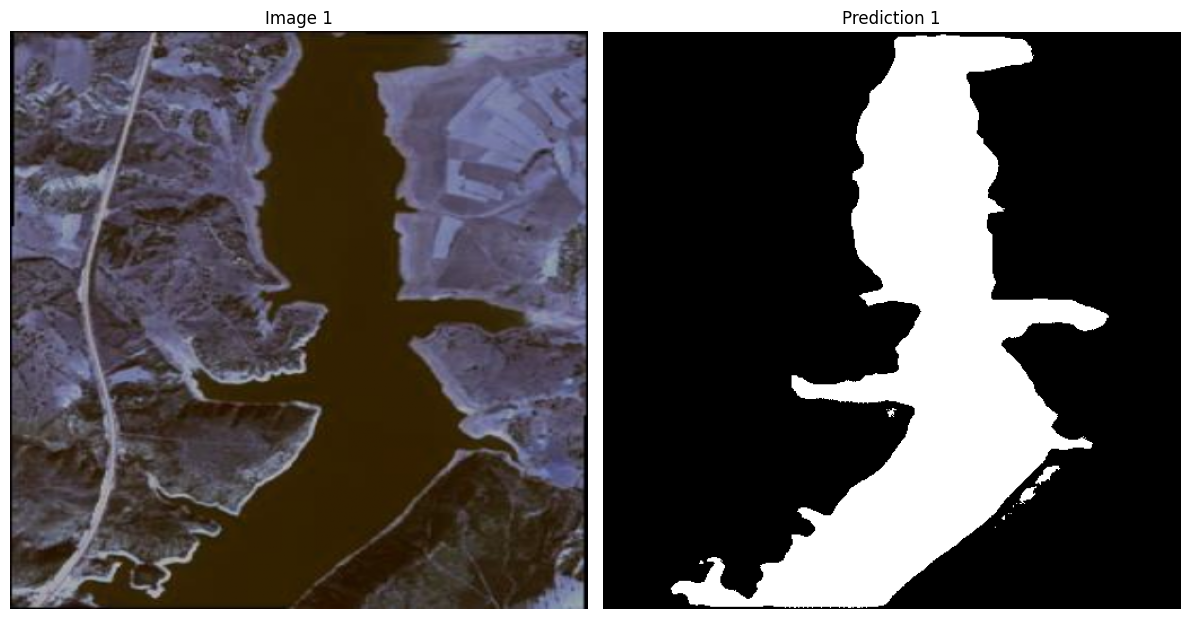

In [14]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model



# Get all the images in the directory
imgs = glob.glob('/content/dataset/pre flood/water_body_2281.jpg')

# Prepare an array to hold the images
img_test = np.zeros((len(imgs), 512, 512, 3))

# Load and preprocess images
for index, i in enumerate(imgs):
    img = cv2.imread(i)
    img = cv2.resize(img, (512, 512))
    img = img / 255.0  # Normalize to [0, 1]
    img_test[index] = img

# Make predictions
pred = model.predict(img_test)
pred = np.where(pred > 0.5, 1, 0)  # Threshold the prediction

# Visualizing the results
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

for i in range(len(imgs)):
    # Display the original image
    axes[0].imshow(img_test[i])
    axes[0].set_title(f'Image {i+1}')
    axes[0].axis('off')

    # Display the corresponding prediction
    axes[1].imshow(pred[i], cmap='gray')  # Show prediction in grayscale
    axes[1].set_title(f'Prediction {i+1}')
    axes[1].axis('off')

plt.tight_layout()

# Save the prediction masks as images
output_folder = '/content/dataset/pre segmented/'  # Change this to your desired output folder
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist


for img in imgs:
    # Get the input image name (without extension)
    input_image_name = os.path.splitext(os.path.basename(img))[0]

    # Save the predicted mask as an image
    pred_mask = (pred[imgs.index(img)] * 255).astype(np.uint8)  # Convert to uint8 for saving

    # Define the output path using the input image name
    output_path = os.path.join(output_folder, f"{input_image_name}.jpg")

    # Save as an image
    cv2.imwrite(output_path, pred_mask)
    print(f"Saved predicted mask: {output_path}")

post flood mask generation

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
Saved predicted mask: /content/dataset/post segmented/post_water_body_2281.jpg


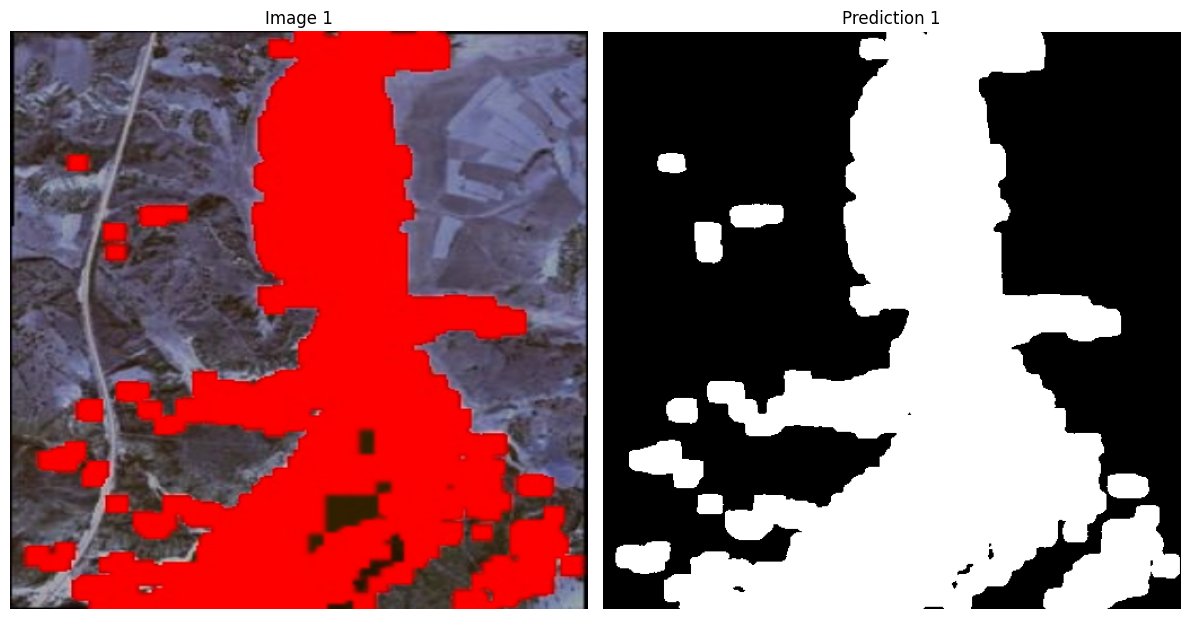

In [15]:
import numpy as np
import cv2
import glob
import matplotlib.pyplot as plt
from tensorflow.keras.models import load_model



# Get all the images in the directory
imgs = glob.glob('/content/dataset/post flood/post_water_body_2281.jpg')

# Prepare an array to hold the images
img_test = np.zeros((len(imgs), 512, 512, 3))

# Load and preprocess images
for index, i in enumerate(imgs):
    img = cv2.imread(i)
    img = cv2.resize(img, (512, 512))
    img = img / 255.0  # Normalize to [0, 1]
    img_test[index] = img

# Make predictions
pred = model.predict(img_test)
pred = np.where(pred > 0.5, 1, 0)  # Threshold the prediction

# Visualizing the results
fig, axes = plt.subplots(1, 2, figsize=(12, 12))

for i in range(len(imgs)):
    # Display the original image
    axes[0].imshow(img_test[i])
    axes[0].set_title(f'Image {i+1}')
    axes[0].axis('off')

    # Display the corresponding prediction
    axes[1].imshow(pred[i], cmap='gray')  # Show prediction in grayscale
    axes[1].set_title(f'Prediction {i+1}')
    axes[1].axis('off')

plt.tight_layout()

# Save the prediction masks as images
output_folder = '/content/dataset/post segmented/'  # Change this to your desired output folder
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist


for img in imgs:
    # Get the input image name (without extension)
    input_image_name = os.path.splitext(os.path.basename(img))[0]

    # Save the predicted mask as an image
    pred_mask = (pred[imgs.index(img)] * 255).astype(np.uint8)  # Convert to uint8 for saving

    # Define the output path using the input image name
    output_path = os.path.join(output_folder, f"{input_image_name}.jpg")

    # Save as an image
    cv2.imwrite(output_path, pred_mask)
    print(f"Saved predicted mask: {output_path}")

Mask Overlap

In [16]:
import os
import torch
import torch.nn as nn
from PIL import Image
import torchvision.transforms as transforms
import numpy as np

# Function to load and preprocess images
def preprocess_image(image_path, image_size=512):
    transform = transforms.Compose([
        transforms.Resize((image_size, image_size)),
        transforms.ToTensor()
    ])
    image = Image.open(image_path).convert('L')  # Ensure grayscale for masks
    return transform(image).unsqueeze(0)  # Add batch dimension

# Function to create the output image
def create_output_image(pre_mask, post_mask, image_size):
    output_image = np.zeros((image_size, image_size, 3), dtype=np.uint8)

    # Existing water bodies (white)
    output_image[(pre_mask == 1) & (post_mask == 1)] = [255, 255, 255]

    # Flooded regions (red)
    output_image[(pre_mask == 0) & (post_mask == 1)] = [255, 0, 0]

    # Non-water bodies (black)
    output_image[(pre_mask == 0) & (post_mask == 0)] = [0, 0, 0]

    return Image.fromarray(output_image)

# Main function for processing a single pair of images
def process_single_image(pre_flood_path, post_flood_path, output_path, image_size=512):
    if not os.path.exists(pre_flood_path):
        print(f"Pre-flood image not found: {pre_flood_path}")
        return

    if not os.path.exists(post_flood_path):
        print(f"Post-flood image not found: {post_flood_path}")
        return

    # Preprocess images
    pre_mask = preprocess_image(pre_flood_path, image_size=image_size)
    post_mask = preprocess_image(post_flood_path, image_size=image_size)

    # Convert masks to binary numpy arrays
    pre_mask = (pre_mask.squeeze().numpy() > 0.5).astype(np.uint8)
    post_mask = (post_mask.squeeze().numpy() > 0.5).astype(np.uint8)

    # Create the output image
    output_image = create_output_image(pre_mask, post_mask, image_size)

    # Save the output image
    output_image.save(output_path)
    print(f"Saved output image: {output_path}")

# Example usage for one image
if __name__ == "__main__":
    pre_flood_path = "/content/dataset/pre segmented/water_body_2281.jpg"
    post_flood_path = "/content/dataset/post segmented/post_water_body_2281.jpg"
    output_path = "/content/dataset/mask overlap/overlap_water_body_2281.jpg"

    process_single_image(pre_flood_path, post_flood_path, output_path)


Saved output image: /content/dataset/mask overlap/overlap_water_body_2281.jpg


Flood Map on SAR Image

In [17]:
import os
from PIL import Image
import numpy as np

# Function to load and preprocess masks to match the target size
def preprocess_mask(mask_path, target_size):
    """
    Preprocess the mask to match the target size.
    """
    # Load the mask
    mask = Image.open(mask_path).convert('RGB')  # Load as RGB to detect red regions

    # Resize the mask to the target size (exact dimensions of the pre-flood image)
    mask = mask.resize(target_size, Image.NEAREST)

    # Convert to numpy array in HWC format
    mask = np.array(mask)
    return mask

# Function to mark only flooded regions in the original image
def mark_flooded_regions(pre_flood_image, flooded_mask, output_path):
    """
    Mark only the red regions (flooded areas) from the flooded mask onto the original image.
    """
    pre_flood_array = np.array(pre_flood_image)

    # Ensure the dimensions of the mask match the dimensions of the pre-flood image
    if flooded_mask.shape[:2] != pre_flood_array.shape[:2]:
        raise ValueError(f"Mask dimensions {flooded_mask.shape[:2]} do not match image dimensions {pre_flood_array.shape[:2]}")

    # Identify red regions in the mask (R > G and R > B)
    red_mask = (flooded_mask[:, :, 0] > flooded_mask[:, :, 1]) & (flooded_mask[:, :, 0] > flooded_mask[:, :, 2])

    # Mark the corresponding regions in the pre-flood image with red
    red_overlay = [255, 0, 0]  # Red color
    pre_flood_array[red_mask] = red_overlay

    # Save the modified image
    marked_image = Image.fromarray(pre_flood_array)
    marked_image.save(output_path)
    print(f"Saved marked image: {output_path}")

# Main processing function for a single image
def process_single_image(pre_flood_path, flooded_mask_path, output_path):
    """
    Process a single image and mask to create an overlay image.
    """
    # Load the pre-flood image
    pre_flood_image = Image.open(pre_flood_path).convert('RGB')
    target_size = pre_flood_image.size  # Get the size of the pre-flood image

    # Preprocess the flooded mask to match the size of the pre-flood image
    flooded_mask = preprocess_mask(flooded_mask_path, target_size)

    # Save the marked image
    mark_flooded_regions(pre_flood_image, flooded_mask, output_path)

# Example usage for a single image
if __name__ == "__main__":
    pre_flood_path = "/content/dataset/pre flood/water_body_2281.jpg"
    flooded_mask_path = "/content/dataset/mask overlap/overlap_water_body_2281.jpg"
    output_path = "/content/dataset/Final Map/2281.jpg"

    process_single_image(pre_flood_path, flooded_mask_path, output_path)


Saved marked image: /content/dataset/Final Map/2281.jpg


Integreted

In [ ]:
import os
import numpy as np
import cv2
from PIL import Image
import tensorflow as tf
from tensorflow.keras.models import load_model
import torchvision.transforms as transforms

# Define the metrics and loss functions

def recall_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    possible_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true, 0, 1)))
    recall = true_positives / (possible_positives + tf.keras.backend.epsilon())
    return recall

def precision_m(y_true, y_pred):
    true_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_true * y_pred, 0, 1)))
    predicted_positives = tf.keras.backend.sum(tf.keras.backend.round(tf.keras.backend.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + tf.keras.backend.epsilon())
    return precision

def f1_m(y_true, y_pred):
    precision = precision_m(y_true, y_pred)
    recall = recall_m(y_true, y_pred)
    return 2 * ((precision * recall) / (precision + recall + tf.keras.backend.epsilon()))

def dsc(y_true, y_pred):
    smooth = 1.
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)
    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    score = (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)
    return score

def dice_loss(y_true, y_pred):
    return 1 - dsc(y_true, y_pred)

# Load the pre-trained model
custom_objects = {"f1_m": f1_m, 'precision_m': precision_m, 'recall_m': recall_m, 'dsc': dsc}
model = load_model('/content/dataset/flood_best.keras', custom_objects=custom_objects)

# Function to preprocess an image

def preprocess_image(image_path, image_size=512):
    image = cv2.imread(image_path)
    image = cv2.resize(image, (image_size, image_size))
    image = image / 255.0  # Normalize to [0, 1]
    return np.expand_dims(image, axis=0)  # Add batch dimension

# Function to predict mask from an image

def predict_mask(image_path):
    preprocessed_image = preprocess_image(image_path)
    pred_mask = model.predict(preprocessed_image)[0]  # Predict the mask
    return (pred_mask > 0.5).astype(np.uint8)  # Binarize the mask

# Function to create an overlay image for flood detection

# Corrected create_flood_overlay function
def create_flood_overlay(pre_mask, post_mask, image_size):
    output_image = np.zeros((image_size, image_size, 3), dtype=np.uint8)

    # Ensure masks are 2D
    pre_mask = pre_mask.squeeze()
    post_mask = post_mask.squeeze()

    # Existing water bodies (white) - Apply where both pre- and post-mask are 1
    output_image[(pre_mask == 1) & (post_mask == 1)] = [255, 255, 255]

    # Flooded regions (red) - Apply where pre-mask is 0 (no water) and post-mask is 1 (flooded)
    output_image[(pre_mask == 0) & (post_mask == 1)] = [255, 0, 0]

    return output_image



# Function to mark flood regions on the original image

def mark_flooded_regions(original_image_path, flood_overlay, output_path):
    original_image = cv2.imread(original_image_path)
    original_image = cv2.resize(original_image, (flood_overlay.shape[1], flood_overlay.shape[0]))

    # Identify red regions in the overlay
    red_mask = (flood_overlay[:, :, 0] == 255) & (flood_overlay[:, :, 1] == 0) & (flood_overlay[:, :, 2] == 0)

    # Overlay red regions on the original image
    original_image[red_mask] = [0, 0, 255]

    # Save the marked image
    cv2.imwrite(output_path, original_image)
    print(f"Saved marked image: {output_path}")

# Integrated function to process pre- and post-flood images

def process_flood_detection(pre_flood_path, post_flood_path, original_image_path, output_path, image_size=512):
    print("Processing images...")

    # Predict masks
    pre_mask = predict_mask(pre_flood_path)
    post_mask = predict_mask(post_flood_path)

    # Create flood overlay
    flood_overlay = create_flood_overlay(pre_mask, post_mask, image_size)

    # Mark flood regions on the original image
    mark_flooded_regions(original_image_path, flood_overlay, output_path)

# Example usage
if __name__ == "__main__":
    pre_flood_path = "/content/dataset/pre flood/water_body_2281.jpg"
    post_flood_path = "/content/dataset/post flood/post_water_body_2281_post.jpg"
    original_image_path = "/content/dataset/pre flood/water_body_2281.jpg"
    output_path = "/content/dataset/Final Map/pred_water_body_2281.jpg"

    process_flood_detection(pre_flood_path, post_flood_path, original_image_path, output_path)


Saved marked image: /content/Final Map/2281.jpg
